In [42]:
pwd

'd:\\Projects\\predict-adult-income\\EDA'

In [43]:
%pip install -r requirement.txt

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirement.txt'


In [44]:
# import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo 

### 1. loading the data

In [45]:
adult = fetch_ucirepo(id=2)

# data (as pandas dataframes) 
X = adult.data.features 
Y = adult.data.targets 
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [46]:
# create data frame 
df = pd.concat([X, Y] , axis = 1)
df.head(5)

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


### 2. Describe the data set

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             48842 non-null  int64
 1   workclass       47879 non-null  str  
 2   fnlwgt          48842 non-null  int64
 3   education       48842 non-null  str  
 4   education-num   48842 non-null  int64
 5   marital-status  48842 non-null  str  
 6   occupation      47876 non-null  str  
 7   relationship    48842 non-null  str  
 8   race            48842 non-null  str  
 9   sex             48842 non-null  str  
 10  capital-gain    48842 non-null  int64
 11  capital-loss    48842 non-null  int64
 12  hours-per-week  48842 non-null  int64
 13  native-country  48568 non-null  str  
 14  income          48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


In [48]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


### 3. Handling missing values

In [49]:
df.isnull().sum()

age                 0
workclass         963
fnlwgt              0
education           0
education-num       0
marital-status      0
occupation        966
relationship        0
race                0
sex                 0
capital-gain        0
capital-loss        0
hours-per-week      0
native-country    274
income              0
dtype: int64

In [50]:
# check are there any garbage values in this data set
cat_cols = []

for i in  list(df.columns):
    if df[i].dtype == "str":
        cat_cols.append(i)

for i in cat_cols:
    uniuqe_list = df[i].unique().sum
    print(f"{i} has : {uniuqe_list}\n")


workclass has : <bound method StringArray.sum of <StringArray>
[       'State-gov', 'Self-emp-not-inc',          'Private',
      'Federal-gov',        'Local-gov',                '?',
     'Self-emp-inc',      'Without-pay',     'Never-worked',
                nan]
Length: 10, dtype: str>

education has : <bound method StringArray.sum of <StringArray>
[   'Bachelors',      'HS-grad',         '11th',      'Masters',
          '9th', 'Some-college',   'Assoc-acdm',    'Assoc-voc',
      '7th-8th',    'Doctorate',  'Prof-school',      '5th-6th',
         '10th',      '1st-4th',    'Preschool',         '12th']
Length: 16, dtype: str>

marital-status has : <bound method StringArray.sum of <StringArray>
[        'Never-married',    'Married-civ-spouse',              'Divorced',
 'Married-spouse-absent',             'Separated',     'Married-AF-spouse',
               'Widowed']
Length: 7, dtype: str>

occupation has : <bound method StringArray.sum of <StringArray>
[     'Adm-clerical',   'E

According to the checking missing values and other garbage values,
- find the three categorical features has null values : workclass, native-country, occupation.
- and find the garbage values (?) as well in same feature aswell.
- and there are dublicates values in target column(income): ['<=50K', '>50K', '<=50K.', '>50K.']

In [51]:
df_cp = df.copy()

### 3.1 Deletion

In [52]:
# drop rows has missing values
df_cp = df_cp.dropna(axis=0)

In [53]:
# drop rows has '?' in features
df_cp = df_cp.replace('?', np.nan)
df_cp = df_cp.dropna(axis=0)

In [54]:
# cleannig income column
df_cp['income'].value_counts()
df_cp['income'] = df_cp['income'].str.strip('.')

In [55]:
df_cp

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48836,33,Private,245211,Bachelors,13,Never-married,Prof-specialty,Own-child,White,Male,0,0,40,United-States,<=50K
48837,39,Private,215419,Bachelors,13,Divorced,Prof-specialty,Not-in-family,White,Female,0,0,36,United-States,<=50K
48839,38,Private,374983,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,50,United-States,<=50K
48840,44,Private,83891,Bachelors,13,Divorced,Adm-clerical,Own-child,Asian-Pac-Islander,Male,5455,0,40,United-States,<=50K


### 3.2 Dublicate value

In [56]:
df_cp.duplicated().sum()

np.int64(47)

In [57]:
# delete the dublicates 
df_cp = df_cp.drop_duplicates()

### 4.Handle Outlier

In [58]:
# get numerical columns
num_cols = [i for i in df_cp.columns if i not in cat_cols]

In [59]:
# use IQR Metod

def handle_outlier_IQR(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)

    IQR = Q3 - Q1

    upper_bound = Q3 + 1.5 * IQR
    lower_bound = Q1 - 1.5 * IQR

    return (data > upper_bound) | (data < lower_bound)


In [60]:
for i in num_cols:
    num_of_outlier = handle_outlier_IQR(df_cp[i]).sum()
    print(f"{i} feature has {num_of_outlier} of outliers")

age feature has 268 of outliers
fnlwgt feature has 1332 of outliers
education-num feature has 290 of outliers
capital-gain feature has 3790 of outliers
capital-loss feature has 2140 of outliers
hours-per-week feature has 11889 of outliers


<Axes: ylabel='hours-per-week'>

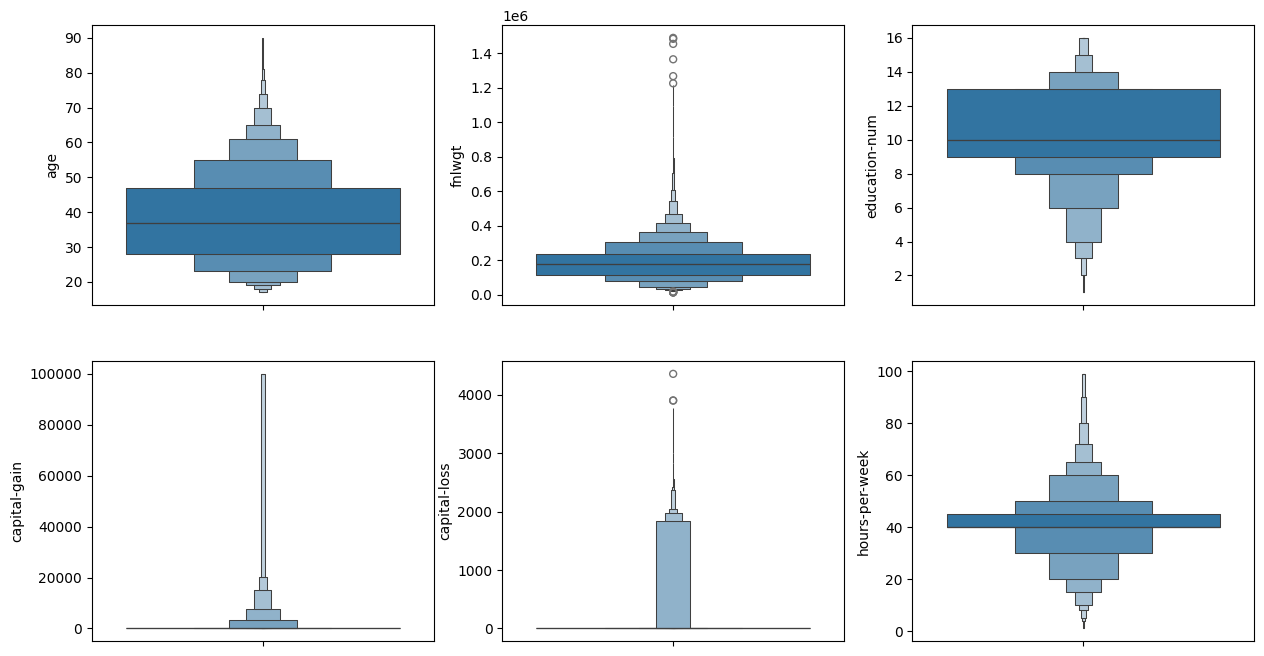

In [61]:
# visualize this via boxplot

fig, axes = plt.subplots(2, 3, figsize=(15,8))

sns.boxenplot(data=df_cp['age'], ax=axes[0,0])
sns.boxenplot(data=df_cp['fnlwgt'], ax=axes[0,1])
sns.boxenplot(data=df_cp['education-num'], ax=axes[0,2])
sns.boxenplot(data=df_cp['capital-gain'], ax=axes[1,0])
sns.boxenplot(data=df_cp['capital-loss'], ax=axes[1,1])
sns.boxenplot(data=df_cp['hours-per-week'], ax=axes[1,2])

There are too many outliers When we remove them it will effect to the Machine learnning model

In [62]:
# check it
num_of_outlier = df_cp[handle_outlier_IQR(df_cp[i])].shape[0]
num_of_data = df_cp.shape[0]

rest_of_data = num_of_data - num_of_outlier
presentage = num_of_data/num_of_outlier

print(f"Total data : {num_of_data} ")
print(f"The Outlier data : {num_of_outlier} ")
print(f"The data remain once delete outliers : {rest_of_data} ")
print(f"The remain data  as  : {presentage} ")

Total data : 45175 
The Outlier data : 11889 
The data remain once delete outliers : 33286 
The remain data  as  : 3.799730843636975 


### 5. Analysis categorical colomn

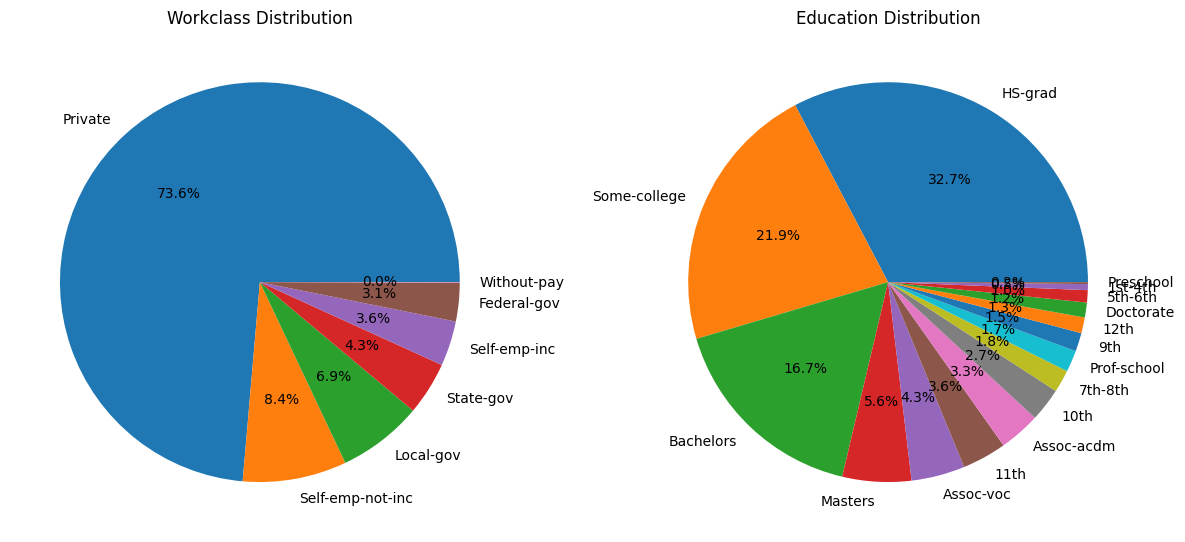

In [68]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Workclass
df_cp['workclass'].value_counts().plot(kind='pie',ax=ax[0], autopct='%1.1f%%')
ax[0].set_title('Workclass Distribution')
ax[0].set_ylabel('')

# Education
df_cp['education'].value_counts().plot(kind='pie',ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Education Distribution')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

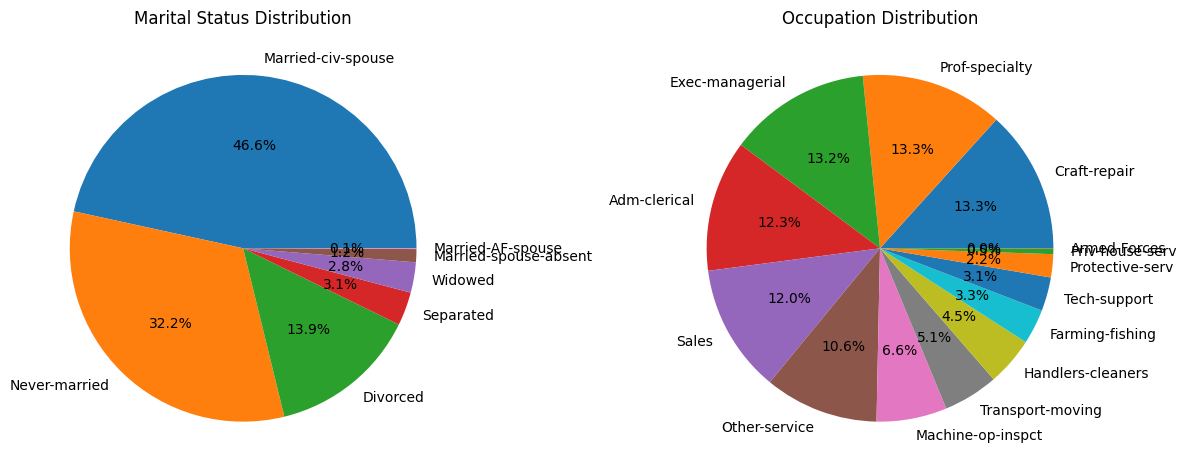

In [69]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

df_cp['marital-status'].value_counts().plot(kind='pie', ax=ax[0], autopct='%1.1f%%')
ax[0].set_title('Marital Status Distribution')
ax[0].set_ylabel('')

df_cp['occupation'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Occupation Distribution')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

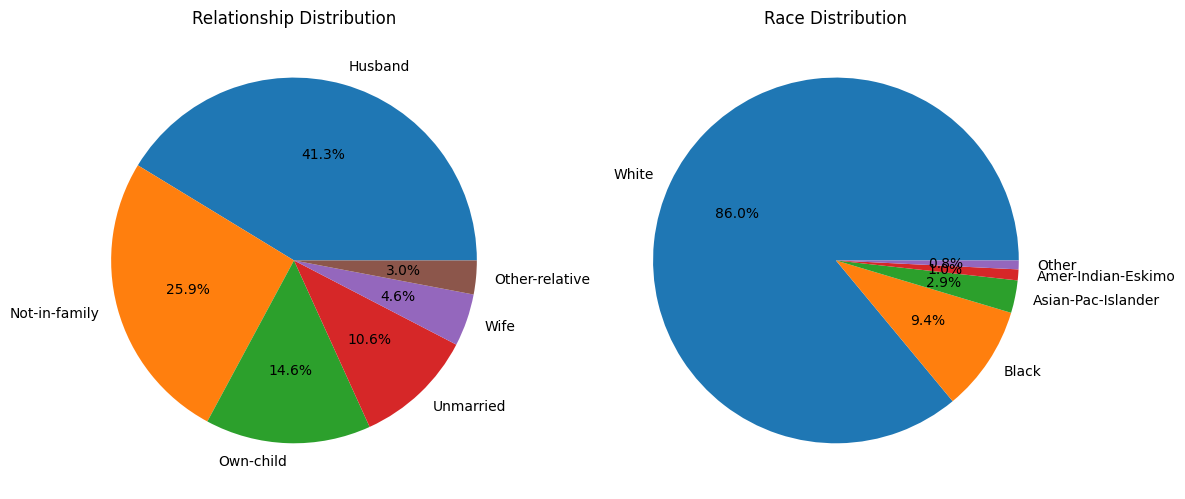

In [70]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

df_cp['relationship'].value_counts().plot(kind='pie', ax=ax[0], autopct='%1.1f%%')
ax[0].set_title('Relationship Distribution')
ax[0].set_ylabel('')

df_cp['race'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Race Distribution')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

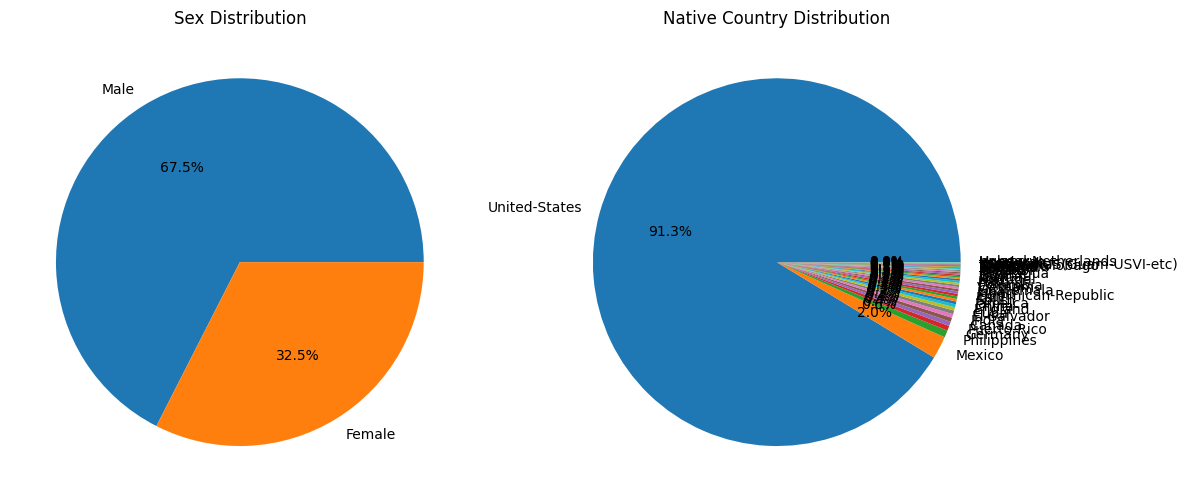

In [71]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

df_cp['sex'].value_counts().plot(kind='pie', ax=ax[0], autopct='%1.1f%%')
ax[0].set_title('Sex Distribution')
ax[0].set_ylabel('')

df_cp['native-country'].value_counts().plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Native Country Distribution')
ax[1].set_ylabel('')

plt.tight_layout()
plt.show()

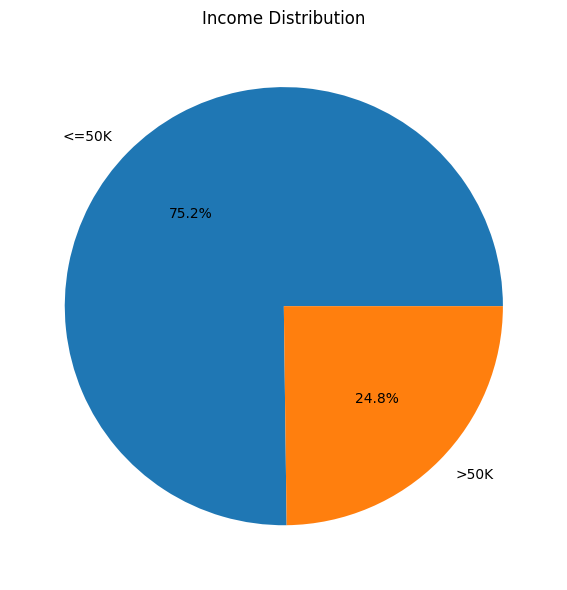

In [72]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

df_cp['income'].value_counts().plot(kind='pie', ax=ax, autopct='%1.1f%%')
ax.set_title('Income Distribution')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

according to this thre are many class imbalance somany feature like Race, native country 
and some feature need to apply binning like native country,nd race lie wise.

### 6.Feature binning

In [87]:
df_cp['education'].value_counts()
# df_cp['occupation'].value_counts()

# df_cp[df_cp['education'] == 'Preschool']['income'].value_counts()

education
HS-grad         14770
Some-college     9887
Bachelors        7559
Masters          2513
Assoc-voc        1958
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           822
Prof-school       785
9th               676
12th              575
Doctorate         544
5th-6th           447
1st-4th           220
Preschool          70
Name: count, dtype: int64

#### 6.1 Education binning 

Education Level and Class

school : Preschool - 1st-4th - 5th-6th - 7th-8th - 9th - 10th - 11th - 12th (0) <br/>
high_school : HS-grad (1) <br/>
college_level : Some-college - Assoc-acdm - Assoc-voc (2) <br/>
higher_education : Bachelors - Masters - Doctorate - Prof-school (3) <br/>

In [88]:
# creating the list seprate the level

school = [
    'Preschool',
    '1st-4th',
    '5th-6th',
    '7th-8th',
    '9th',
    '10th',
    '11th',
    '12th'
]

higher_education = [
    'Bachelors',
    'Masters',
    'Doctorate',
    'Prof-school'
]

college_level = ['Some-college', 'Assoc-acdm', 'Assoc-voc']
high_school = ['HS-grad']

In [91]:
def binning_education_level(level):
    if level in school:
        return "school"
    elif level in higher_education:
        return "higher_education"
    elif level in college_level:
        return "college_level"
    elif level in high_school:
        return "high_school"
    else:
        return "Invalid"

In [92]:
df_cp['education'] = df_cp['education'].apply(binning_education_level)

In [95]:
df_cp['education'].value_counts()

education
high_school         14770
college_level       13352
higher_education    11401
school               5652
Name: count, dtype: int64

Native Country and Class

United-States : Represents individuals from the United States <br/>
Other Countries  : Represents all non–United States countries grouped together <br/>

In [107]:
countries = list(df_cp['native-country'].unique())
usa = countries.pop(countries.index('United-States'))


In [108]:
def binning_country(country):
    if country in countries:
        return "other"
    elif country in usa:
        return "usa"
    else:
        return "Invalid"

In [109]:
df_cp['native-country'] = df_cp['native-country'].apply(binning_country)

In [110]:
df_cp['native-country'].value_counts()

native-country
usa      41256
other     3919
Name: count, dtype: int64

In [113]:
df_cp['occupation'].value_counts()

occupation
Craft-repair         6010
Prof-specialty       6001
Exec-managerial      5980
Adm-clerical         5535
Sales                5405
Other-service        4805
Machine-op-inspct    2965
Transport-moving     2316
Handlers-cleaners    2045
Farming-fishing      1475
Tech-support         1419
Protective-serv       975
Priv-house-serv       230
Armed-Forces           14
Name: count, dtype: int64